In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
import gymnasium as gym
import ale_py
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.callbacks import BaseCallback
 
gym.register_envs(ale_py)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Environment inspection 

In [ ]:

env = gym.make("ALE/MsPacman-v5")
obs, info = env.reset()

print("=== SPACES ===")
print("Obs space:", env.observation_space)
print("Act space:", env.action_space)
print("Actions:", env.unwrapped.get_action_meanings())

print("\n=== INFO DICT KEYS ===")
print(info)

print("\n=== ALE PROPERTIES ===")
ale = env.unwrapped.ale
print("Lives:", ale.lives())
print("Frame number:", ale.getFrameNumber())
print("Episode frames:", ale.getEpisodeFrameNumber())
print("RAM size:", len(ale.getRAM()))
print("Legal actions:", ale.getLegalActionSet())
print("Min actions:", ale.getMinimalActionSet())

env.close()

=== SPACES ===
Obs space: Box(0, 255, (210, 160, 3), uint8)
Act space: Discrete(9)
Actions: ['NOOP', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT']

=== INFO DICT KEYS ===
{'lives': 3, 'episode_frame_number': 0, 'frame_number': 0}

=== ALE PROPERTIES ===
Lives: 3
Frame number: 0
Episode frames: 0
RAM size: 128
Legal actions: [<Action.NOOP: 0>, <Action.FIRE: 1>, <Action.UP: 2>, <Action.RIGHT: 3>, <Action.LEFT: 4>, <Action.DOWN: 5>, <Action.UPRIGHT: 6>, <Action.UPLEFT: 7>, <Action.DOWNRIGHT: 8>, <Action.DOWNLEFT: 9>, <Action.UPFIRE: 10>, <Action.RIGHTFIRE: 11>, <Action.LEFTFIRE: 12>, <Action.DOWNFIRE: 13>, <Action.UPRIGHTFIRE: 14>, <Action.UPLEFTFIRE: 15>, <Action.DOWNRIGHTFIRE: 16>, <Action.DOWNLEFTFIRE: 17>]
Min actions: [<Action.NOOP: 0>, <Action.UP: 2>, <Action.RIGHT: 3>, <Action.LEFT: 4>, <Action.DOWN: 5>, <Action.UPRIGHT: 6>, <Action.UPLEFT: 7>, <Action.DOWNRIGHT: 8>, <Action.DOWNLEFT: 9>]


In [ ]:
import torch
print(torch.__version__)        
print(torch.cuda.is_available()) 

2.6.0+cu124
True


## Reward Shaping Wrapper

In [ ]:
class RewardShapingWrapper(gym.Wrapper):
    GHOST_REWARDS = {200, 400, 800, 1600}
    FRUIT_REWARDS = {100, 300, 500, 700, 1000, 2000, 3000, 5000}
    POWER_PELLET_REWARD = 50
    REGULAR_PELLET_REWARD = 10
    POWER_PELLET_DURATION = 150  
 
    def __init__(
        self,
        env,
        ghost_chain_bonus = 12.0,
        pellet_streak_bonus = 0.03,
        fruit_multiplier = 1.05,
        death_penalty = 0.0,
    ):
        super().__init__(env)
        self.ghost_chain_bonus = ghost_chain_bonus
        self.pellet_streak_bonus = pellet_streak_bonus
        self.fruit_multiplier = fruit_multiplier
        self.death_penalty = death_penalty
 
        # Mutable state
        self._prev_lives = None
        self.ghosts_eaten = 0     
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
 
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._prev_lives = None
        self.ghosts_eaten = 0
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
        return obs, info
 
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        shaped_reward = reward
        raw = int(reward)
 
        # Life tracker initialisation
        current_lives = info.get("lives", 3)
        if self._prev_lives is None:
            self._prev_lives = current_lives
 
        # Power-pellet window bookkeeping
        if self._power_pellet_active:
            self._power_pellet_steps += 1
            if self._power_pellet_steps > self.POWER_PELLET_DURATION:
                self._power_pellet_active = False
                self._power_pellet_steps = 0
                self.ghosts_eaten = 0
 
        # Ghost chain bonus
        if raw in self.GHOST_REWARDS:
            self.ghosts_eaten += 1
            if self.ghosts_eaten > 1:
                shaped_reward += self.ghost_chain_bonus * (self.ghosts_eaten - 1)
 
        # Pellet streak
        if raw == self.REGULAR_PELLET_REWARD:
            self._pellet_streak += 1
            self._steps_since_pellet = 0
            shaped_reward += self.pellet_streak_bonus * self._pellet_streak
 
        elif raw == self.POWER_PELLET_REWARD:
            self._pellet_streak += 1
            self._steps_since_pellet = 0
            shaped_reward += self.pellet_streak_bonus * self._pellet_streak
            self._power_pellet_active = True
            self._power_pellet_steps = 0
            self.ghosts_eaten = 0
 
        else:
            self._steps_since_pellet += 1
            if self._steps_since_pellet > 8:
                self._pellet_streak = 0
 
        # Fruit multiplier 
        if raw in self.FRUIT_REWARDS:
            shaped_reward += (self.fruit_multiplier - 1.0) * raw
 
        # Death penalty
        if current_lives < self._prev_lives:
            shaped_reward += self.death_penalty
        self._prev_lives = current_lives
 
        return obs, shaped_reward, terminated, truncated, info
    

## Experimental Conditions

In [ ]:
CONDITIONS = {
    "Baseline": {
        "wrapper": None,
        "color": "blue",
        "description": "Default ALE rewards only",
    },
    "Expert Shaping": {
        "wrapper": "expert",
        "ghost_chain_bonus": 12.0,
        "pellet_streak_bonus": 0.0,
        "fruit_multiplier": 1.5,
        "death_penalty": 0.0,
        "color": "orange",
        "description": "Chain + fruit, no death penalty",
    },
    "Expert Shaping + Death Penalty": {
        "wrapper": "expert",
        "ghost_chain_bonus": 12.0,
        "pellet_streak_bonus": 0.0,
        "fruit_multiplier": 1.5,
        "death_penalty": -1.0,
        "color": "purple",
        "description": "Chain + fruit + death penalty",
    },
}
 
print("Conditions defined:")
for name, cfg in CONDITIONS.items():
    print(f"  {name:35s} — {cfg['description']}")
    

Conditions defined:
  Baseline                            — Default ALE rewards only
  Expert Shaping                      — Chain + fruit, no death penalty
  Expert Shaping + Death Penalty      — Chain + fruit + death penalty


## Progress Callback (tracks metrics per episode)

In [ ]:
class ExperimentCallback(BaseCallback):
    def __init__(self, condition_name, verbose= 0):
        super().__init__(verbose)
        self.condition_name = condition_name
        self.episode_rewards = []  
        self.episode_shaped_rewards = []  
        self.episode_lengths = []
        self.episode_ghosts_eaten = []
 
        self._shaped_accum = 0.0
        self._length_accum = 0
 
    def _on_step(self):
        self._shaped_accum += float(self.locals["rewards"][0])
        self._length_accum += 1
 
        if self.locals["dones"][0]:
            info = self.locals["infos"][0]
 
            # True unshaped score 
            true_r = info.get("episode", {}).get("r", self._shaped_accum)
 
            # Retrieve ghosts_eaten from the innermost wrapper that has it.
            inner_env = self.training_env.envs[0]
            while hasattr(inner_env, "env"):
                if hasattr(inner_env, "ghosts_eaten"):
                    break
                inner_env = inner_env.env
            ghosts = getattr(inner_env, "ghosts_eaten", 0)
 
            self.episode_rewards.append(float(true_r))
            self.episode_shaped_rewards.append(float(self._shaped_accum))
            self.episode_lengths.append(int(self._length_accum))
            self.episode_ghosts_eaten.append(int(ghosts))
 
            n = len(self.episode_rewards)
            if n % 50 == 0:
                w = min(20, n)
                print(
                    f"  [{self.condition_name}] Ep {n:>4} | "
                    f"Steps {self.num_timesteps:>8,} | "
                    f"True: {np.mean(self.episode_rewards[-w:]):>7.1f} | "
                    f"Shaped: {np.mean(self.episode_shaped_rewards[-w:]):>7.1f} | "
                    f"Len: {np.mean(self.episode_lengths[-w:]):>5.0f}"
                )
 
            self._shaped_accum = 0.0
            self._length_accum = 0
 
        return True
    

## Training Function

In [ ]:
def make_env(condition_cfg, seed=42):
    def _init():
        env = gym.make("ALE/MsPacman-v5", render_mode=None)
        if condition_cfg.get("wrapper") == "expert":
            env = RewardShapingWrapper(
                env,
                ghost_chain_bonus = condition_cfg.get("ghost_chain_bonus", 0.0),
                pellet_streak_bonus = condition_cfg.get("pellet_streak_bonus", 0.0),
                fruit_multiplier = condition_cfg.get("fruit_multiplier", 1.0),
                death_penalty = condition_cfg.get("death_penalty", 0.0),
            )
        env = AtariWrapper(env, clip_reward=False)
        env.reset(seed=seed)
        return env
 
    return _init
 
def train_condition(condition_name, condition_cfg, total_timesteps = 1_000_000, seed = 42):
    print(f"\n{'='*62}")
    print(f"Training: {condition_name}")
    print(f"Config: {condition_cfg['description']}")
    print(f"Steps: {total_timesteps:,}, Seed: {seed}")
 
    vec_env = DummyVecEnv([make_env(condition_cfg, seed)])
    vec_env = VecFrameStack(vec_env, n_stack=4)
 
    model = PPO(
        "CnnPolicy",
        vec_env,
        n_steps = 1024,
        batch_size = 256,
        n_epochs = 4,
        gamma = 0.99,
        learning_rate = 2.5e-4,
        clip_range = 0.1,
        verbose = 0,
        seed = seed,
    )
 
    callback = ExperimentCallback(condition_name)
    model.learn(total_timesteps=total_timesteps, callback=callback)
 
    steps_str = f"{total_timesteps // 1_000_000}M"
    file_name = "_".join(condition_name.replace("+", "").lower().split())
    save_path = f"ppo_pacman_{file_name}_{steps_str}_seed{seed}_1024n_steps"
 
    model.save(save_path)
    print(f"  Model saved: {save_path}.zip")
 
    log_path = f"training_{file_name}_{steps_str}_seed{seed}.json"
    with open(log_path, "w") as f:
        json.dump({
            "condition": condition_name,
            "seed": seed,
            "total_steps": total_timesteps,
            "episode_rewards": callback.episode_rewards,
            "episode_shaped_rewards": callback.episode_shaped_rewards,
            "episode_lengths": callback.episode_lengths,
            "episode_ghosts_eaten": callback.episode_ghosts_eaten,
        }, f)
    print(f"  Training log: {log_path}")
 
    vec_env.close()
    return model, callback


## Train Loop for 1_000_000 steps * 3 seeds

In [ ]:
SEED_SHORT = [42, 99, 123]
TOTAL_STEPS_SHORT = 1_000_000
TOTAL_STEPS_MID = 3_000_000
TOTAL_STEPS_LONG = 7_000_000
SEED_MID = 42
SEED_LONG = 42

In [ ]:
results_multiseed = {name: [] for name in CONDITIONS}

for name, cfg in CONDITIONS.items():
    for seed in SEED_SHORT:
        try:
            model, callback = train_condition(name, cfg, total_timesteps=TOTAL_STEPS_SHORT, seed=seed)
            results_multiseed[name].append({
                "seed": seed,
                "model": model,
                "episode_rewards": callback.episode_rewards,
                "episode_shaped_rewards": callback.episode_shaped_rewards,
                "episode_lengths": callback.episode_lengths,
                "episode_ghosts_eaten": callback.episode_ghosts_eaten,
                "total_steps": TOTAL_STEPS_SHORT,
            })
            print(f"{name} with seed {seed} complete.")
        except Exception as exc:
            print(f"{name} with seed {seed} failed: {exc}")
            results_multiseed[name].append(None)

print(f"\nAll conditions trained {TOTAL_STEPS_SHORT:,} steps each.")



Training: Baseline
Config: Default ALE rewards only
Steps: 1,000,000, Seed: 42
  [Baseline] Ep   50 | Steps    2,315 | True:   190.0 | Shaped:   190.0 | Len:    48
  [Baseline] Ep  100 | Steps    4,545 | True:   184.0 | Shaped:   184.0 | Len:    51
  [Baseline] Ep  150 | Steps    6,977 | True:   167.0 | Shaped:   167.0 | Len:    50
  [Baseline] Ep  200 | Steps    9,226 | True:   134.5 | Shaped:   134.5 | Len:    42
  [Baseline] Ep  250 | Steps   11,662 | True:   156.5 | Shaped:   156.5 | Len:    52
  [Baseline] Ep  300 | Steps   14,337 | True:   124.5 | Shaped:   124.5 | Len:    50
  [Baseline] Ep  350 | Steps   16,959 | True:   183.0 | Shaped:   183.0 | Len:    50
  [Baseline] Ep  400 | Steps   19,652 | True:   191.5 | Shaped:   191.5 | Len:    52
  [Baseline] Ep  450 | Steps   22,265 | True:   126.0 | Shaped:   126.0 | Len:    53
  [Baseline] Ep  500 | Steps   25,269 | True:   169.5 | Shaped:   169.5 | Len:    54
  [Baseline] Ep  550 | Steps   27,823 | True:   141.5 | Shaped:   141.

## Training loop for 3_000_000 steps

In [ ]:
results_mid= {}

for name, cfg in CONDITIONS.items():
        try:
            model, callback = train_condition(name, cfg, total_timesteps=TOTAL_STEPS_MID, seed=SEED_MID)
            results_mid[name] = {
                "seed": SEED_MID,
                "model": model,
                "episode_rewards": callback.episode_rewards,
                "episode_shaped_rewards": callback.episode_shaped_rewards,
                "episode_lengths": callback.episode_lengths,
                "episode_ghosts_eaten": callback.episode_ghosts_eaten,
                "total_steps": TOTAL_STEPS_MID,
            }
            print(f"Mid run: {name} complete.")
        except Exception as exc:
            print(f"Mid run: {name} failed: {exc}")
            results_mid[name] = None

print(f"\nAll conditions trained {TOTAL_STEPS_MID:,} steps each.")


## Training loop for 7_000_000

In [ ]:
results_long = {}

for name, cfg in CONDITIONS.items():
        try:
            model, callback = train_condition(name, cfg, total_timesteps=TOTAL_STEPS_LONG, seed=SEED_LONG)
            results_long[name] = {
                "seed": SEED_LONG,
                "model": model,
                "episode_rewards": callback.episode_rewards,
                "episode_shaped_rewards": callback.episode_shaped_rewards,
                "episode_lengths": callback.episode_lengths,
                "episode_ghosts_eaten": callback.episode_ghosts_eaten,
                "total_steps": TOTAL_STEPS_LONG,
            }
            print(f"Long run: {name} complete.")
        except Exception as exc:
            print(f"Long run: {name} failed: {exc}")
            results_long[name] = None

print(f"\nAll conditions trained {TOTAL_STEPS_LONG:,} steps each.")


## Evaluation Function

In [ ]:
def evaluate_agent(model, n_episodes=100, seed=99):
    def _make_eval_env():
        env = gym.make("ALE/MsPacman-v5")
        env = AtariWrapper(env, clip_reward=False)
        env.reset(seed=seed)
        return env
 
    eval_env = DummyVecEnv([_make_eval_env])
    eval_env = VecFrameStack(eval_env, n_stack=4)
 
    GHOST_REWARD_VALUES = {200, 400, 800, 1600}
 
    scores, lengths, ghost_chains, ghosts_eaten, score_per_step = [], [], [], [], []
 
    for _ in range(n_episodes):
        obs = eval_env.reset()
        total_score = 0.0
        length = 0
        done  = False
        current_chain = 0
        max_chain = 0
        ep_ghosts = 0
        prev_lives = 3
 
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done_arr, info = eval_env.step(action)
            done = bool(done_arr[0])
            r = float(reward[0])
            total_score += r
            length      += 1
 
            # Ghost chain tracking 
            raw_r = int(round(r))
            if raw_r in GHOST_REWARD_VALUES:
                current_chain += 1
                max_chain = max(max_chain, current_chain)
                ep_ghosts += 1
            # power pellet resets chain
            elif raw_r == 50:         
                current_chain = 0
 
            # Death resets chain
            current_lives = info[0].get("lives", prev_lives)
            if current_lives < prev_lives:
                current_chain = 0
            prev_lives = current_lives
 
        scores.append(total_score)
        lengths.append(length)
        ghost_chains.append(max_chain)
        ghosts_eaten.append(ep_ghosts)
        score_per_step.append(total_score / length if length > 0 else 0.0)
 
    eval_env.close()
 
    return {
        "scores": np.array(scores),
        "lengths": np.array(lengths),
        "ghost_chains": np.array(ghost_chains),
        "ghosts_eaten": np.array(ghosts_eaten),
        "score_per_step": np.array(score_per_step),
    }


## Evaluate Multi_Seed (1M)

In [ ]:
eval_results_multiseed = {name: [] for name in CONDITIONS}

for name, seed_runs in results_multiseed.items():
    for run in seed_runs:
        if run is None:
            continue
        seed = run["seed"]
        print(f"Evaluating {name} — seed {seed} ...")
        er = evaluate_agent(run["model"], n_episodes=100, seed=99)
        eval_results_multiseed[name].append({"seed": seed, **er})

        model  = "_".join(name.replace("+", "").lower().split())
        save_name = f"eval_{model}_1M_seed{seed}_1024n_steps.json"
        with open(save_name, "w") as f:
            json.dump(
                {k: v.tolist() for k, v in er.items()} |
                {"condition": name, "steps": TOTAL_STEPS_SHORT, "seed": seed},
                f,
            )
        print(f"  Saved → {save_name}")
 
display(pd.DataFrame({
    name: {
        "Avg Score": round(float(np.mean(np.concatenate([s["scores"] for s in seed_list]))), 1),
        "Std": round(float(np.std(np.concatenate([s["scores"] for s in seed_list]))), 1),
        "Survival": round(float(np.mean(np.concatenate([s["lengths"] for s in seed_list]))), 1),
        "Ghost Chain": round(float(np.mean(np.concatenate([s["ghost_chains"] for s in seed_list]))), 2),
        "Ghosts/ep": round(float(np.mean(np.concatenate([s["ghosts_eaten"] for s in seed_list]))), 1),
        "Score/step": round(float(np.mean(np.concatenate([s["score_per_step"] for s in seed_list]))), 3),
    }
    for name, seed_list in eval_results_multiseed.items()
    if seed_list
}).T)


Evaluating Baseline — seed 42 ...
  Saved → eval_baseline_1M_seed42.json
Evaluating Baseline — seed 99 ...
  Saved → eval_baseline_1M_seed99.json
Evaluating Baseline — seed 123 ...
  Saved → eval_baseline_1M_seed123.json
Evaluating Expert Shaping — seed 42 ...
  Saved → eval_expert_shaping_1M_seed42.json
Evaluating Expert Shaping — seed 99 ...
  Saved → eval_expert_shaping_1M_seed99.json
Evaluating Expert Shaping — seed 123 ...
  Saved → eval_expert_shaping_1M_seed123.json
Evaluating Expert Shaping + Death Penalty — seed 42 ...
  Saved → eval_expert_shaping_death_penalty_1M_seed42.json
Evaluating Expert Shaping + Death Penalty — seed 99 ...
  Saved → eval_expert_shaping_death_penalty_1M_seed99.json
Evaluating Expert Shaping + Death Penalty — seed 123 ...
  Saved → eval_expert_shaping_death_penalty_1M_seed123.json


,Avg Score,Std,Survival,Ghost Chain,Ghosts/ep,Score/step
Baseline,171.2,146.4,46.9,0.03,0.0,3.285
Expert Shaping,145.8,128.9,44.3,0.04,0.0,3.112
Expert Shaping + Death Penalty,125.2,152.4,45.9,0.03,0.0,2.261


## Evaluate Mid (3M)

In [ ]:
eval_results_mid = {}

for name, data in results_mid.items():
    if data is None:
        print(f"  Skipping {name}, mid training failed.")
        continue
    print(f"Evaluating {name} — 3M (indicative) ...")
    er = evaluate_agent(data["model"], n_episodes=100, seed=99)
    eval_results_mid[name] = er

    model  = "_".join(name.replace("+", "").lower().split())
    save_name = f"eval_{model}_3M_seed{SEED_MID}_1024n_steps.json"
    with open(save_name, "w") as f:
        json.dump(
            {k: v.tolist() for k, v in er.items()} |
            {"condition": name, "steps": TOTAL_STEPS_MID, "seed": SEED_MID},
            f,
        )
    print(f"  Saved → {save_name}")
 
display(pd.DataFrame({
    name: {
        "Avg Score": round(float(np.mean(er["scores"])), 1),
        "Std": round(float(np.std(er["scores"])), 1),
        "Survival": round(float(np.mean(er["lengths"])), 1),
        "Ghost Chain": round(float(np.mean(er["ghost_chains"])), 2),
        "Ghosts/ep": round(float(np.mean(er["ghosts_eaten"])), 1),
        "Score/step": round(float(np.mean(er["score_per_step"])), 3),
    }
    for name, er in eval_results_mid.items()
}).T)


## Evaluate Long (7M)

In [ ]:
eval_results_long = {}

for name, data in results_long.items():
    if data is None:
        print(f"  Skipping {name}, long training failed.")
        continue
    print(f"Evaluating {name} — 7M (indicative) ...")
    er = evaluate_agent(data["model"], n_episodes=100, seed=99)
    eval_results_long[name] = er

    model  = "_".join(name.replace("+", "").lower().split())
    save_name = f"eval_{model}_7M_seed{SEED_LONG}_1024n_steps.json"
    with open(save_name, "w") as f:
        json.dump(
            {k: v.tolist() for k, v in er.items()} |
            {"condition": name, "steps": TOTAL_STEPS_LONG, "seed": SEED_LONG},
            f,
        )
    print(f"  Saved → {save_name}")
 
display(pd.DataFrame({
    name: {
        "Avg Score": round(float(np.mean(er["scores"])), 1),
        "Std": round(float(np.std(er["scores"])), 1),
        "Survival": round(float(np.mean(er["lengths"])), 1),
        "Ghost Chain": round(float(np.mean(er["ghost_chains"])), 2),
        "Ghosts/ep": round(float(np.mean(er["ghosts_eaten"])), 1),
        "Score/step": round(float(np.mean(er["score_per_step"])), 3),
    }
    for name, er in eval_results_long.items()
}).T)


## Aggregate multi_seed results (1M)

In [ ]:
eval_results_1M_agg = {}
for name in CONDITIONS:
    seed_evals = [e for e in eval_results_multiseed[name] if e is not None]
    if not seed_evals:
        continue
    eval_results_1M_agg[name] = {
        "scores": np.concatenate([e["scores"] for e in seed_evals]),
        "lengths": np.concatenate([e["lengths"] for e in seed_evals]),
        "ghost_chains": np.concatenate([e["ghost_chains"] for e in seed_evals]),
        "ghosts_eaten": np.concatenate([e["ghosts_eaten"] for e in seed_evals]),
        "score_per_step": np.concatenate([e["score_per_step"] for e in seed_evals]),
    }

per_seed_means_1M = {
    name: [float(np.mean(e["scores"])) for e in eval_results_multiseed[name] if e is not None]
    for name in CONDITIONS
}

train_final_1M = {}
for name in CONDITIONS:
    valid = [r for r in results_multiseed[name] if r is not None]
    if valid:
        per_seed = [
            float(np.mean(r["episode_rewards"][-100:]))
            if len(r["episode_rewards"]) >= 100
            else float(np.mean(r["episode_rewards"]))
            for r in valid
        ]
        train_final_1M[name] = float(np.mean(per_seed))

print("Multi-seed (1M) per-seed mean scores:")
display(pd.DataFrame({
    name: {
        f"Seed {e['seed']}": round(float(np.mean(e["scores"])), 1)
        for e in eval_results_multiseed[name] if e is not None
    }
    for name in CONDITIONS
}).T)

print("\nMulti-seed (1M) aggregated summary (300 episodes):")
display(pd.DataFrame({
    name: {
        "Mean Score": round(float(np.mean(er["scores"])), 1),
        "Std (ep)": round(float(np.std(er["scores"])), 1),
        "Std (seeds)": round(float(np.std(per_seed_means_1M[name])), 1),
        "Survival": round(float(np.mean(er["lengths"])), 1),
        "Ghost Chain": round(float(np.mean(er["ghost_chains"])), 2),
        "Ghosts/ep": round(float(np.mean(er["ghosts_eaten"])), 1),
        "Score/step": round(float(np.mean(er["score_per_step"])), 3),
    }
    for name, er in eval_results_1M_agg.items()
}).T)


Multi-seed (1M) per-seed mean scores:


,Seed 42,Seed 99,Seed 123
Baseline,214.8,183.7,115.1
Expert Shaping,218.5,162.9,55.9
Expert Shaping + Death Penalty,57.7,203.8,114.0



Multi-seed (1M) aggregated summary (300 episodes):


,Mean Score,Std (ep),Std (seeds),Survival,Ghost Chain,Ghosts/ep,Score/step
Baseline,171.2,146.4,41.7,46.9,0.03,0.0,3.285
Expert Shaping,145.8,128.9,67.5,44.3,0.04,0.0,3.112
Expert Shaping + Death Penalty,125.2,152.4,60.2,45.9,0.03,0.0,2.261


## Summary tables for mid and long (3M & 7M)

In [ ]:
for label, eval_res in [
    ("3M", eval_results_mid),
    ("7M", eval_results_long),
]:
    if not eval_res:
        print(f"\n{label}: no results available.")
        continue
    print(f"\n{label}:")
    display(pd.DataFrame({
        name: {
            "Mean Score": round(float(np.mean(er["scores"])), 1),
            "Std": round(float(np.std(er["scores"])), 1),
            "Survival": round(float(np.mean(er["lengths"])), 1),
            "Ghost Chain": round(float(np.mean(er["ghost_chains"])), 2),
            "Ghosts/ep": round(float(np.mean(er["ghosts_eaten"])), 1),
            "Score/step": round(float(np.mean(er["score_per_step"])), 3),
        }
        for name, er in eval_res.items()
    }).T)
    

## Utility functions

In [ ]:
def smooth(arr, window=50):
    arr = np.asarray(arr, dtype=float)
    if len(arr) < window:
        return arr
    return np.convolve(arr, np.ones(window) / window, mode="valid")


def steps_to_threshold(episode_rewards, episode_lengths, threshold, window=50):
    rewards = np.asarray(episode_rewards, dtype=float)
    lengths = np.asarray(episode_lengths, dtype=float)
    smoothed = smooth(rewards, window)
    above = np.where(smoothed >= threshold)[0]
    if len(above) == 0:
        return None, None
    ep_idx     = int(above[0]) + (window - 1)
    step_count = int(np.sum(lengths[: ep_idx + 1]))
    return ep_idx, step_count


## Learning Efficiency Analysis Multi_Seed (1M)

In [ ]:
print("Learning Efficiency 1M steps (per-seed threshold averaged)")

efficiency_1M = {}
for name in CONDITIONS:
    valid_runs = [r for r in results_multiseed[name] if r is not None]
    if not valid_runs:
        continue

    ep_list, step_list, thresh_list = [], [], []
    for run in valid_runs:
        rewards   = np.asarray(run["episode_rewards"], dtype=float)
        smoothed  = smooth(rewards, window=50)
        own_best  = float(np.max(smoothed)) if len(smoothed) else 0.0
        threshold = 0.5 * own_best
        thresh_list.append(threshold)
        ep, steps = steps_to_threshold(rewards, run["episode_lengths"], threshold)
        ep_list.append(ep)
        step_list.append(steps)

    valid_eps   = [e for e in ep_list if e is not None]
    valid_steps = [s for s in step_list if s is not None]

    efficiency_1M[name] = {
        "threshold (mean)": round(float(np.mean(thresh_list)), 1),
        "eps to threshold (mean)": round(float(np.mean(valid_eps)), 0) if valid_eps else "Never",
        "steps to threshold (mean)": f"{int(np.mean(valid_steps)):,}" if valid_steps else "Never",
        "seeds reached": f"{len(valid_eps)}/{len(valid_runs)}",
        "final train avg": round(train_final_1M.get(name, float("nan")), 1),
        "eval score (mean)": round(float(np.mean(eval_results_1M_agg[name]["scores"])), 1)
                                if name in eval_results_1M_agg else None,
    }

display(pd.DataFrame(efficiency_1M).T)


Learning Efficiency 1M steps (per-seed threshold averaged)


,threshold (mean),eps to threshold (mean),steps to threshold (mean),seeds reached,final train avg,eval score (mean)
Baseline,195.9,398.0,"18,858",3/3,205.1,171.2
Expert Shaping,186.1,483.0,"21,316",3/3,245.9,145.8
Expert Shaping + Death Penalty,179.6,353.0,"14,794",3/3,230.0,125.2


## Learning Curve Multi_Seed (1M)

In [ ]:

def plot_learning_curves_multiseed(results_ms, CONDITIONS, total_steps, window=None):
    fig, ax = plt.subplots(figsize=(11, 5))

    for name, seed_runs in results_ms.items():
        valid = [r for r in seed_runs if r is not None]
        if not valid:
            continue
        color = CONDITIONS[name]["color"]

        all_smoothed = []
        for run in valid:
            s = pd.Series(run["episode_rewards"]).rolling(window, min_periods=1).mean().values
            ax.plot(s, color=color, linewidth=1, alpha=0.2)
            all_smoothed.append(s)

        min_len    = min(len(s) for s in all_smoothed)
        mean_curve = np.array([s[:min_len] for s in all_smoothed]).mean(axis=0)
        ax.plot(mean_curve, color=color, linewidth=2.5, label=name)

    ax.set_xlabel("Episode")
    ax.set_ylabel("True Game Score (rolling mean, window=50)")
    ax.set_title(
        f"Learning Curves: {total_steps:,} steps | "
        f"{len(SEED_SHORT)} seeds (faint lines) + mean (solid)"
    )
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"plot_learning_curves_{total_steps // 1_000_000}M_multiseed_1024n_steps.png", dpi=130)
    plt.show()


plot_learning_curves_multiseed(results_multiseed, CONDITIONS, TOTAL_STEPS_SHORT)

NameError: name 'results_multiseed' is not defined

## Learning Efficiency Analysis 3M and 7M

In [ ]:
for label, res_dict, eval_dict in [
    ("3M", results_mid,  eval_results_mid),
    ("7M", results_long, eval_results_long),
]:
    if not res_dict:
        print(f"\n{label}: no results.")
        continue
    print(f"\nLearning Efficiency {label}")
    eff = {}
    for name, data in res_dict.items():
        if data is None or name not in eval_dict:
            continue
        rewards = np.asarray(data["episode_rewards"], dtype=float)
        smoothed = smooth(rewards, window=50)
        own_best = float(np.max(smoothed)) if len(smoothed) else 0.0
        threshold = 0.5 * own_best
        final_avg = (float(np.mean(rewards[-100:])) if len(rewards) >= 100
                     else float(np.mean(rewards)))
        ep, steps = steps_to_threshold(rewards, data["episode_lengths"], threshold)
        eff[name] = {
            "threshold": round(threshold, 1),
            "episodes": ep if ep is not None else "Never",
            "steps": f"{steps:,}" if steps is not None else "Never",
            "final train avg": round(final_avg, 1),
            "eval score": round(float(np.mean(eval_dict[name]["scores"])), 1),
        }
    display(pd.DataFrame(eff).T)

## Learning Curve 3M and 7M

In [ ]:
def plot_learning_curves_single(res_dict, CONDITIONS, total_steps, suffix="", window=None):
    fig, ax = plt.subplots(figsize=(11, 5))
    for name, data in res_dict.items():
        if data is None:
            continue
        s = pd.Series(data["episode_rewards"]).rolling(window, min_periods=1).mean()
        ax.plot(s, color=CONDITIONS[name]["color"], linewidth=2, label=name)
    ax.set_xlabel("Episode")
    ax.set_ylabel("True Game Score (rolling mean, window=50)")
    ax.set_title(f"Learning Curves: {total_steps:,} steps{suffix}")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"plot_learning_curves_{total_steps // 1_000_000}M_1024n_steps.png", dpi=130)
    plt.show()


plot_learning_curves_single(results_mid,  CONDITIONS, TOTAL_STEPS_MID)
plot_learning_curves_single(results_long, CONDITIONS, TOTAL_STEPS_LONG)

## Score Distribution Box Plot

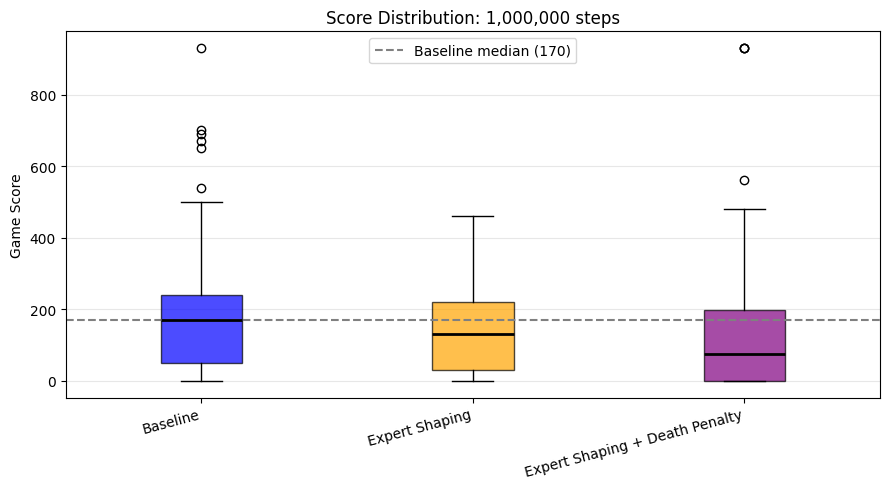

eval_results_mid not available — skipping 3M plot
eval_results_long not available — skipping 7M plot


In [ ]:
def plot_score_distribution(eval_res, CONDITIONS, total_steps, suffix=""):
    names  = [n for n in CONDITIONS if n in eval_res]
    colors = [CONDITIONS[n]["color"] for n in names]

    fig, ax = plt.subplots(figsize=(9, 5))
    bp = ax.boxplot(
        [eval_res[n]["scores"] for n in names],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    if "Baseline" in eval_res:
        bm = np.median(eval_res["Baseline"]["scores"])
        ax.axhline(bm, color="gray", linestyle="--", linewidth=1.5,
                   label=f"Baseline median ({bm:.0f})")

    ax.set_xticks(range(1, len(names) + 1))
    ax.set_xticklabels(names, rotation=15, ha="right")
    ax.set_ylabel("Game Score")
    ax.set_title(f"Score Distribution: {total_steps:,} steps{suffix}")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"plot_score_distribution_{total_steps // 1_000_000}M_1024n_steps.png", dpi=130)
    plt.show()

plot_score_distribution(eval_results_1M_agg, CONDITIONS, TOTAL_STEPS_SHORT)
if "eval_results_mid" in dir() and eval_results_mid:
    plot_score_distribution(eval_results_mid, CONDITIONS, TOTAL_STEPS_MID)
else:
    print("eval_results_mid not available — skipping 3M plot")

if "eval_results_long" in dir() and eval_results_long:
    plot_score_distribution(eval_results_long, CONDITIONS, TOTAL_STEPS_LONG)
else:
    print("eval_results_long not available — skipping 7M plot")

## Reward Hacking Detection 

In [ ]:
def hacking_analysis(train_finals, eval_res, label):
    if "Baseline" not in train_finals or "Baseline" not in eval_res:
        print(f"\n[{label}] Baseline missing — skipping.")
        return

    b_train = train_finals["Baseline"]
    b_eval  = float(np.mean(eval_res["Baseline"]["scores"]))

    hacking = {}
    for name in CONDITIONS:
        if name not in train_finals or name not in eval_res:
            continue
        t     = train_finals[name]
        e     = float(np.mean(eval_res[name]["scores"]))
        ratio = round(e / t, 2) if t > 0 else 1.0

        if name == "Baseline":
            verdict = "Reference"
        elif t > b_train and e < b_eval and ratio < 0.6:
            verdict = "HACKING"
        elif t > b_train and e < b_eval:
            verdict = "LIKELY"
        elif e < b_eval:
            verdict = "Underperforms"
        else:
            verdict = "Clean"

        hacking[name] = {
            "Train Reward": round(t, 1),
            "Eval Score": round(e, 1),
            "Ratio": ratio,
            "vs Baseline": round(e - b_eval, 1),
            "Verdict": verdict,
        }

    print(f"\nReward Hacking Analysis {label}")
    print("Ratio = eval / train  (1.0 = aligned, <0.6 = likely hacking)")
    display(pd.DataFrame(hacking).T)

def _final_train_avg(results_dict):
    return {
        name: (
            float(np.mean(data["episode_rewards"][-100:]))
            if data is not None and len(data["episode_rewards"]) >= 100
            else float(np.mean(data["episode_rewards"])) if data is not None
            else float("nan")
        )
        for name, data in results_dict.items()
    }

hacking_analysis(train_final_1M, eval_results_1M_agg)
hacking_analysis(_final_train_avg(results_mid), eval_results_mid)
hacking_analysis(_final_train_avg(results_long), eval_results_long)


REWARD HACKING ANALYSIS — 1,000,000 steps
Ratio = eval / train  (1.0 = aligned, <0.6 = likely hacking)


,Train Reward,Eval Score,Ratio,vs BL,Verdict
Baseline,238.3,214.8,0.9,0.0,Reference
Expert Shaping,264.7,218.5,0.83,3.7,Clean
Expert Shaping + Death Penalty,207.5,57.7,0.28,-157.1,Underperforms


## Statistical Summary 

In [ ]:
def statistical_summary(eval_res, train_finals, label):
    if not eval_res:
        print(f"\n[{label}] No evaluation results available.")
        return

    b_score  = float(np.mean(eval_res["Baseline"]["scores"]))  \
               if "Baseline" in eval_res else float("nan")
    b_length = float(np.mean(eval_res["Baseline"]["lengths"])) \
               if "Baseline" in eval_res else float("nan")

    print(f"\n{'='*62}")
    print(f"Statistical Summary — {label}")

    display(pd.DataFrame({
        name: {
            "Mean Score": round(float(np.mean(er["scores"])),1),
            "Std (ep)": round(float(np.std(er["scores"])),1),
            "Median Score": round(float(np.median(er["scores"])),1),
            "Max Score": int(np.max(er["scores"])),
            "Min Score": int(np.min(er["scores"])),
            "Survival": round(float(np.mean(er["lengths"])),1),
            "Std Survival": round(float(np.std(er["lengths"])),1),
            "Ghost Chain": round(float(np.mean(er["ghost_chains"])),2),
            "Ghosts/ep": round(float(np.mean(er["ghosts_eaten"])),1),
            "Score/step": round(float(np.mean(er["score_per_step"])),3),
        }
        for name, er in eval_res.items()
        if name in CONDITIONS
    }).T)


    if "Baseline" not in eval_res:
        return

    print(f"\nComparison vs Baseline — {label}")
    display(pd.DataFrame({
        name: {
            "Score Diff": round(float(np.mean(er["scores"])) - b_score,1),
            "Beats BL?": "YES" if float(np.mean(er["scores"])) > b_score else "NO",
            "Survival Diff": round(float(np.mean(er["lengths"])) - b_length,1),
            "Survival Dir":  (
                "+" if float(np.mean(er["lengths"])) - b_length > 1 else
                "-" if float(np.mean(er["lengths"])) - b_length < -1 else
                "="
            ),
            "Train Avg": round(train_finals.get(name, float("nan")), 1),
        }
        for name, er in eval_res.items()
        if name in CONDITIONS
    }).T)

statistical_summary(eval_results_1M_agg, train_final_1M,)
statistical_summary(eval_results_mid, _final_train_avg(results_mid),)
statistical_summary(eval_results_long, _final_train_avg(results_long),)


FULL STATISTICAL SUMMARY-1M steps


,Mean Score,Std,Max Score,Survival,Ghost Chain,Ghosts/ep,Score/step
Baseline,214.8,171.9,930.0,47.6,0.08,0.0,4.092
Expert Shaping,218.5,116.6,440.0,41.2,0.11,0.0,5.118
Expert Shaping + Death Penalty,57.7,47.0,120.0,31.0,0.00,0.0,1.635



Comparison vs Baseline


,Score Diff,Beats BL?,Survival Diff,Survival Dir
Baseline,0.0,NO,0.0,=
Expert Shaping,3.7,YES,-6.5,↓
Expert Shaping + Death Penalty,-157.1,NO,-16.6,↓


## Evaluation of the saved models

In [3]:
NAME_TO_SLUG = {
    "Baseline": "baseline",
    "Expert Shaping":                 "expert_shaping",
    "Expert Shaping + Death Penalty": "expert_shaping_death_penalty",  
}


def load_eval(eval_path):
    """Load a cached evaluation json and return numpy arrays."""
    with open(eval_path) as f:
        raw = json.load(f)
    return {
        k: np.array(v)
        for k, v in raw.items()
        if k not in ("condition", "steps", "seed")
    }


def load_training_log(training_path, total_steps, model):
    """Load a training log json and return a results dict."""
    if os.path.exists(training_path):
        with open(training_path) as f:
            td = json.load(f)
        return {
            "episode_rewards":        td["episode_rewards"],
            "episode_shaped_rewards": td.get("episode_shaped_rewards",
                                             td["episode_rewards"]),
            "episode_lengths":        td["episode_lengths"],
            "episode_ghosts_eaten":   td.get("episode_ghosts_eaten", []),
            "total_steps":            total_steps,
            "model":                  model,
        }
    print(f"  No training log found: {training_path}")
    return {
        "episode_rewards": [], "episode_shaped_rewards": [],
        "episode_lengths": [], "episode_ghosts_eaten":   [],
        "total_steps": total_steps, "model": model,
    }


# ── 1M multi-seed ────────────────────────────────────────────────────────────
print("=" * 62)
print("Loading 1M multi-seed results")
results_multiseed  = {name: [] for name in CONDITIONS}
eval_results_multiseed = {name: [] for name in CONDITIONS}

for name, slug in NAME_TO_SLUG.items():
    for seed in SEED_SHORT:
        steps_str    = "1M"
        model_path   = f"ppo_pacman_{slug}_{steps_str}_seed{seed}"
        training_path = f"training_{slug}_{steps_str}_seed{seed}.json"
        eval_path    = f"eval_{slug}_{steps_str}_seed{seed}.json"

        try:
            model = PPO.load(model_path)
            print(f"  Loaded {model_path}.zip")
        except FileNotFoundError:
            print(f"  {model_path}.zip not found — skipping {name} seed {seed}")
            results_multiseed[name].append(None)
            continue

        if os.path.exists(eval_path):
            er = load_eval(eval_path)
            print(f"    Eval loaded from cache: {eval_path}")
        else:
            er = evaluate_agent(model, n_episodes=100, seed=99)
            with open(eval_path, "w") as f:
                json.dump(
                    {k: v.tolist() for k, v in er.items()} |
                    {"condition": name, "steps": TOTAL_STEPS_SHORT, "seed": seed},
                    f,
                )
            print(f"    Eval complete + saved: {eval_path}")

        eval_results_multiseed[name].append({"seed": seed, **er})
        run = load_training_log(training_path, TOTAL_STEPS_SHORT, model)
        run["seed"] = seed
        results_multiseed[name].append(run)


# ── Rebuild 1M aggregated eval dict ──────────────────────────────────────────
eval_results_1M_agg = {}
for name in CONDITIONS:
    seed_evals = [e for e in eval_results_multiseed[name] if e is not None]
    if not seed_evals:
        continue
    eval_results_1M_agg[name] = {
        "scores":         np.concatenate([e["scores"]         for e in seed_evals]),
        "lengths":        np.concatenate([e["lengths"]        for e in seed_evals]),
        "ghost_chains":   np.concatenate([e["ghost_chains"]   for e in seed_evals]),
        "ghosts_eaten":   np.concatenate([e["ghosts_eaten"]   for e in seed_evals]),
        "score_per_step": np.concatenate([e["score_per_step"] for e in seed_evals]),
    }

# Rebuild train_final_1M
train_final_1M = {}
for name in CONDITIONS:
    valid = [r for r in results_multiseed[name] if r is not None]
    if valid:
        per_seed = [
            float(np.mean(r["episode_rewards"][-100:]))
            if len(r["episode_rewards"]) >= 100
            else float(np.mean(r["episode_rewards"]))
            for r in valid
        ]
        train_final_1M[name] = float(np.mean(per_seed))


# ── 3M single seed ────────────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("Loading 3M single-seed results (indicative)")
results_mid    = {}
eval_results_mid = {}

for name, slug in NAME_TO_SLUG.items():
    steps_str     = "3M"
    model_path    = f"ppo_pacman_{slug}_{steps_str}_seed{SEED_MID}"
    training_path = f"training_{slug}_{steps_str}_seed{SEED_MID}.json"
    eval_path     = f"eval_{slug}_{steps_str}_seed{SEED_MID}.json"

    try:
        model = PPO.load(model_path)
        print(f"  Loaded {model_path}.zip")
    except FileNotFoundError:
        print(f"  {model_path}.zip not found — skipping {name}")
        results_mid[name] = None
        continue

    if os.path.exists(eval_path):
        er = load_eval(eval_path)
        print(f"    Eval loaded from cache: {eval_path}")
    else:
        er = evaluate_agent(model, n_episodes=100, seed=99)
        with open(eval_path, "w") as f:
            json.dump(
                {k: v.tolist() for k, v in er.items()} |
                {"condition": name, "steps": TOTAL_STEPS_MID, "seed": SEED_MID},
                f,
            )
        print(f"    Eval complete + saved: {eval_path}")

    eval_results_mid[name] = er
    results_mid[name] = load_training_log(training_path, TOTAL_STEPS_MID, model)


# ── 7M single seed ────────────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("Loading 7M single-seed results (indicative)")
results_long    = {}
eval_results_long = {}

for name, slug in NAME_TO_SLUG.items():
    steps_str     = "7M"
    model_path    = f"ppo_pacman_{slug}_{steps_str}_seed{SEED_LONG}"
    training_path = f"training_{slug}_{steps_str}_seed{SEED_LONG}.json"
    eval_path     = f"eval_{slug}_{steps_str}_seed{SEED_LONG}.json"

    try:
        model = PPO.load(model_path)
        print(f"  Loaded {model_path}.zip")
    except FileNotFoundError:
        print(f"  {model_path}.zip not found — skipping {name}")
        results_long[name] = None
        continue

    if os.path.exists(eval_path):
        er = load_eval(eval_path)
        print(f"    Eval loaded from cache: {eval_path}")
    else:
        er = evaluate_agent(model, n_episodes=100, seed=99)
        with open(eval_path, "w") as f:
            json.dump(
                {k: v.tolist() for k, v in er.items()} |
                {"condition": name, "steps": TOTAL_STEPS_LONG, "seed": SEED_LONG},
                f,
            )
        print(f"    Eval complete + saved: {eval_path}")

    eval_results_long[name] = er
    results_long[name] = load_training_log(training_path, TOTAL_STEPS_LONG, model)


# ── Quick summary ─────────────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("1M aggregated summary (300 episodes per condition):")
display(pd.DataFrame({
    name: {
        "Mean Score":  round(float(np.mean(er["scores"])),        1),
        "Std":         round(float(np.std(er["scores"])),         1),
        "Survival":    round(float(np.mean(er["lengths"])),       1),
        "Ghost Chain": round(float(np.mean(er["ghost_chains"])),  2),
        "Ghosts/ep":   round(float(np.mean(er["ghosts_eaten"])),  1),
        "Score/step":  round(float(np.mean(er["score_per_step"])),3),
    }
    for name, er in eval_results_1M_agg.items()
}).T)

for label, eval_res in [
    ("3M — single seed (indicative)", eval_results_mid),
    ("7M — single seed (indicative)", eval_results_long),
]:
    if not eval_res:
        continue
    print(f"\n{label}:")
    display(pd.DataFrame({
        name: {
            "Mean Score":  round(float(np.mean(er["scores"])),        1),
            "Std":         round(float(np.std(er["scores"])),         1),
            "Survival":    round(float(np.mean(er["lengths"])),       1),
            "Ghost Chain": round(float(np.mean(er["ghost_chains"])),  2),
            "Ghosts/ep":   round(float(np.mean(er["ghosts_eaten"])),  1),
            "Score/step":  round(float(np.mean(er["score_per_step"])),3),
        }
        for name, er in eval_res.items()
    }).T)

print(f"\nLoad complete.")

Loading 1M multi-seed results


NameError: name 'CONDITIONS' is not defined